In [1]:
import pandas as pd
import numpy as np
import time

jahr = '2024'

if jahr == '2025':
    wetter_csv='Wetter/2024_Wetter_Station_020_Mengen_hh24.csv'
else:
    wetter_csv='Wetter/2024_Stunde_077_Hartheim.csv'

wetter=pd.read_csv(wetter_csv,sep=';',decimal=',')
wetter['Datum']=pd.to_datetime(wetter['Tag']+' '+wetter['Stunde'],format='%d.%m.%Y %H:%M',utc=True)
wetter=wetter.set_index('Datum')

In [2]:
Windkraft_je_ms=pd.read_csv('Windanlagen_kw_pro_ms.csv',sep=';')
Windkraft_je_ms['max W/m²']=Windkraft_je_ms.apply(lambda row: pow(min(row['m/s'],15),3)*0.5*1.2, axis= 1)
Windkraft_je_ms['m/s cp']=Windkraft_je_ms['m/s']
Windkraft_je_ms.set_index('m/s',drop=True,inplace=True)
Windkraft_je_ms['rel_V172-7.2']=Windkraft_je_ms['V172-7.2']/Windkraft_je_ms['V172-7.2'].max()
#Windkraft_je_ms.head()

In [3]:
faktor=5.7
# Basis Eki
basis=wetter['MAX_WV200max']
# Basis Helgoland
#basis=preis_menge['Wind Helgoland']
#faktor=11.6
fak='{}'.format(faktor)
fak_halbe='{}'.format(faktor/2)
max_wind=500
wetter['Wind '+fak+' m/s']=round(faktor*basis/basis.mean()*2)/2
wetter['Wind '+fak+' m/s']=wetter.apply(lambda row: min(row['Wind '+fak+' m/s'],max_wind),axis= 1)

wetter['max W/m²']=wetter.apply(lambda row: pow(min(row['Wind '+fak+' m/s'],15),3)*0.5*1.2, axis= 1)
wetter['pow H'+fak+' V172']=wetter['Wind '+fak+' m/s'].map(Windkraft_je_ms['rel_V172-7.2'])

wetter['pow H'+fak+' V172']=wetter['pow H'+fak+' V172'].fillna(0)
wetter['z Anzahl']=1

In [4]:
waermebedarf=0.066 # kWh/h*K
# unter 22°C - 
pv_prod=67/5000 # 60kWh pro 5000 Globalstrahlung
pv_prod=pv_prod   # halbierung wegen Wind
wind_pow=2*0         # 3 kW Anteilige Leistung

In [5]:
wetter['PV']=pv_prod*wetter['SUM_GS200']
#Windkraft_je_ms['max W/m²']=Windkraft_je_ms.apply(lambda row: pow(min(row['m/s'],15),3)*0.5*1.2, axis= 1)
wetter['WP']=wetter.apply(lambda row: max(22-row['AVG_TA200'],0.5)*waermebedarf, axis=1)
wetter['Wind']=wetter['pow H'+fak+' V172']*wind_pow
wetter['Haus']=0.35
wetter['delta']=wetter['PV']+wetter['Wind']-wetter['WP']-wetter['Haus']

In [16]:
r_arr=[]
#liste=[0,1,2,3,4,5,6,7,8,9,10,12,15,20,21,22,23,24,25,26,50,75,80,100,500,2599,2600,2700]
liste=[1,15,100,0,50,51]

start_time = time.time()
#for speicherkap in():
for speicherkap in liste:
    speicher_alt=0
    #speicherkap=100
    wetter['Speicher']=0.0
    wetter['VerbrauchSpeicher']=0.0
    
    for cur in range(2):
        a_speicher=[]
        a_verbrauchspeicher=[]
        a_einspeicher=[]
        
        for index, row in wetter.iterrows():
            idx=index
    
            
            
            #rw=wetter.iloc[idx]
            delta=row['PV']+row['Wind']-row['WP']-row['Haus']
            #delta=row.iloc[11]+row.iloc[13]-row.iloc[12]-row.iloc[14]
    
            speicher_neu=max(min(speicherkap,delta+speicher_alt),0)
    
            verbrauch=max(speicher_alt-speicher_neu,0)
            einspeicher=min(speicher_alt-speicher_neu,0)
            
            a_speicher.append(speicher_neu)
            a_verbrauchspeicher.append(verbrauch)
            a_einspeicher.append(einspeicher)
            speicher_alt=speicher_neu
        wetter['VerbrauchSpeicher']=a_verbrauchspeicher
        wetter['Einspeicher']=a_einspeicher
        wetter['Speicher']=a_speicher

    wetter['Netz +']=wetter.apply(lambda row: max(row['WP']+row['Haus']-row['PV']-row['Wind']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter['Netz -']=wetter.apply(lambda row: min(row['WP']+row['Haus']-row['PV']-row['Wind']-row['VerbrauchSpeicher']-row['Einspeicher'],0), axis=1)
    wetter=wetter.round(6)
    r_arr.append([speicherkap,wetter['VerbrauchSpeicher'].sum()])
print("--- %s seconds ---" % (time.time() - start_time))    

--- 6.56447434425354 seconds ---


In [17]:
df=wetter.reset_index()
df['Monat']=df['Datum'].dt.month
df['Jahr']=df['Datum'].dt.year

df['Speicher min']=df['Speicher']
df['Speicher max']=df['Speicher']

#agf={'PV':'sum','WP':'sum','Haus':'sum','Wind':'sum','Netz +':'sum','Netz -':'sum','VerbrauchSpeicher':'sum','Einspeicher':'sum','Speicher':["min", "max"]}
agf={'PV':'sum','WP':'sum','Haus':'sum','Wind':'sum','Netz +':'sum','Netz -':'sum','VerbrauchSpeicher':'sum','Einspeicher':'sum','Speicher min':"min",'Speicher max':"max"}
cols=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher min','Speicher max']
res=pd.pivot_table(df,index='Monat',values=cols, aggfunc=agf,margins=True,margins_name=jahr)

#res=pd.crosstab(index=df['Monat'], columns=df['Region'], values = df['Sales'], aggfunc=['sum', 'mean'], margins=True)

#pd.pivot_table(df,index='Monat',values=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher'], aggfunc={'PV':'sum','Speicher':('max','min')},margins=True,margins_name=jahr)

In [18]:
res

,Einspeicher,Haus,Netz +,Netz -,PV,Speicher max,Speicher min,VerbrauchSpeicher,WP,Wind
Monat,,,,,,,,,,
1,-153.29468,260.4,784.45726,0.00000,396.44704,19.48978,0.00000,142.59378,909.8034,0.0
2,-395.99500,243.6,215.09648,0.00000,662.43972,42.84796,0.00000,370.68440,608.6256,0.0
3,-552.74380,260.4,24.06822,-268.46702,1144.19250,51.00000,0.00000,542.67990,629.3298,0.0
4,-440.21076,252.0,0.00000,-732.71070,1503.75470,51.00000,13.02150,438.21736,517.0506,0.0
5,-304.24208,260.4,0.00000,-1395.87310,1989.53150,51.00000,35.99628,304.83148,333.8478,0.0
6,-210.64572,252.0,0.00000,-1698.40300,2136.25212,51.00000,40.07148,211.10800,186.3114,0.0
7,-191.83600,260.4,0.00000,-2013.85392,2411.94640,51.00000,41.63216,190.30812,136.1646,0.0
8,-198.13136,260.4,0.00000,-1947.22358,2325.91438,51.00000,40.62222,197.26116,117.4206,0.0
9,-342.96942,252.0,0.00000,-663.29582,1223.90374,51.00000,24.22728,344.93110,310.5696,0.0


In [20]:
df = pd.DataFrame(r_arr)
v = [0]+[r_arr[i+1][0]-r_arr[i][0] for i in range(len(r_arr)-1)]
r = [0]+[r_arr[i+1][1]-r_arr[i][1] for i in range(len(r_arr)-1)]
df[2]=v
df[3]=r
df[4]=df.apply(lambda row: row[3]/row[2] if (row[2]>0).any() else 0, axis=1)
#df=df[(df[0]>0) & (df[0]<200)]

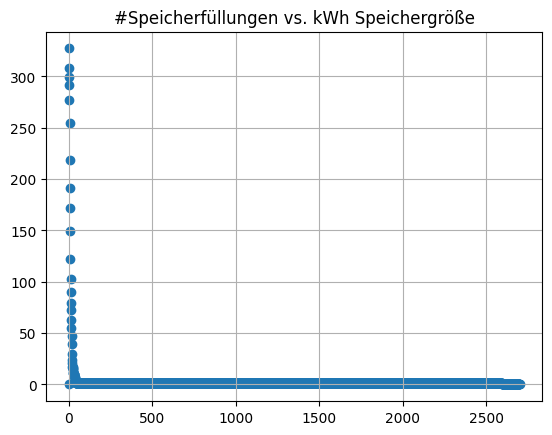

In [30]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots()
#ax.scatter([r[0] for r in r_arr],[r[1] for r in r_arr])

ax.scatter(df[0],df[4])
#ax.set_xscale('log')
#ax.set_yscale('log')

#ax.set_ylim([0,300])
#ax.set_xlim([0.1,30])
ax.grid(True)
ax.set_title("#Speicherfüllungen vs. kWh Speichergröße")
plt.show()

In [11]:
df.rename(columns={0:'Speichergröße',1:'Gesamtspeichernutzen',2:'vorg. Zeile',3:'Delta Speicher Vorzeile',4:'Delta pro kWh Speicher'})

,vorg. Zeile,Delta Speicher Vorzeile,Delta pro kWh Speicher
0,0,0,0


In [12]:
speicherkap

NameError: name 'speicherkap' is not defined

In [19]:
delta=wetter['PV']+wetter['Wind']-wetter['WP']-wetter['Haus']
import time
start_time = time.time()
f=0
a=[]
for i in range(len(delta)):
    f+=delta.iloc[i]
    #print(f"Row {i}: {delta.iloc[i]}") 
print("--- %s seconds ---" % (time.time() - start_time))

start_time = time.time()

for i in delta.index:  # Here, index defaults to 0, 1, 2
    f+=delta.loc[i]
print("--- %s seconds ---" % (time.time() - start_time))

start_time = time.time()
r_arr=[]
#liste=[0,1,2,3,4,5,6,7,8,9,10,12,15,20,25,26,50,75,80,100,500,2599,2600,2700]
liste=range(2700)
for speicherkap in liste:
    speicherstand=0
    for n in range(2):
        a_speicherstand=[]
        a_speicherverbrauch=[]
        for change_speicher in delta:
            speicher_alt=speicherstand
            speicherstand=max(min(change_speicher+speicherstand,speicherkap),0)
            verbrauch_speicher=max(speicher_alt-speicherstand,0)
            a_speicherstand.append(speicherstand)
            a_speicherverbrauch.append(verbrauch_speicher)
    r_arr.append([speicherkap,round(sum(a_speicherverbrauch),6)])            
print("--- %s seconds ---" % (time.time() - start_time))

--- 0.043082237243652344 seconds ---
--- 0.09156060218811035 seconds ---
--- 38.71544814109802 seconds ---


In [14]:
start_time = time.time()
n=0
for i in range(100000):
    n+=1
    f=1 if 1>0 else 2
    #f=min(1,2)
print("--- %s seconds ---" % (time.time() - start_time))

--- 0.022726058959960938 seconds ---


In [15]:
agf={'PV':'sum','WP':'sum','Haus':'sum','Wind':'sum','Netz +':'sum','Netz -':'sum','VerbrauchSpeicher':'sum','Einspeicher':'sum','Speicher':["min", "max"]}
cols=['PV','WP','Haus','Wind','Netz +','Netz -','VerbrauchSpeicher','Einspeicher','Speicher']
pd.pivot_table(df,index='Monat',values=cols, aggfunc=agf)

KeyError: 'PV'

In [ ]:
b.apply(lambda x:[y if y >= 0 else 0 for y in x])

In [ ]:
row.iloc[11]+row.iloc[13]-row.iloc[12]-row.iloc[14]